In [12]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from nbtools import auto_plot_style
from jupyfun import filter_df
from nbtools import normhist

In [2]:
%matplotlib inline

auto_plot_style()

In [3]:
def summarize(df):
    dx = df.x.max() - df.x.min()
    dy = df.y.max() - df.y.min()
    dz = df.z.max() - df.z.min()
    dr = max([dx, dy, dz])
    e  = df.energy.sum() * 1e3
    return pd.DataFrame(dict(dx=dx, dy=dy, dz=dz, dr=dr, e=e), index=[0])

In [4]:
folder    = Path("/media/gonzalo/se/data/COLINA/kr_extent/")
filenames = sorted(folder.glob("*.h5"))

data = []
for filename in filenames:
    print(filename)
    gas  =       filename.stem.split("_")[1]
    p    = float(filename.stem.split("_")[2][:-3])
    hits = pd.read_hdf(filename, "/MC/hits")
    hits = hits.loc[hits.label=="ACTIVE"]
    hits = (hits.groupby("event_id")
                .apply(summarize)
                .reset_index(level=1, drop=True)
                .reset_index()
           )
    hits = hits.assign(gas=gas, p=p)
    data.append(hits)

data = pd.concat(data, ignore_index=True)

/media/gonzalo/se/data/COLINA/kr_extent/kr_GAr_1.0bar.h5
/media/gonzalo/se/data/COLINA/kr_extent/kr_GAr_1.2bar.h5
/media/gonzalo/se/data/COLINA/kr_extent/kr_GAr_1.4bar.h5
/media/gonzalo/se/data/COLINA/kr_extent/kr_GAr_1.6bar.h5
/media/gonzalo/se/data/COLINA/kr_extent/kr_GAr_1.8bar.h5
/media/gonzalo/se/data/COLINA/kr_extent/kr_GAr_2.0bar.h5
/media/gonzalo/se/data/COLINA/kr_extent/kr_GAr_2.2bar.h5
/media/gonzalo/se/data/COLINA/kr_extent/kr_GAr_2.4bar.h5
/media/gonzalo/se/data/COLINA/kr_extent/kr_GAr_2.6bar.h5
/media/gonzalo/se/data/COLINA/kr_extent/kr_GAr_2.8bar.h5
/media/gonzalo/se/data/COLINA/kr_extent/kr_GAr_3.0bar.h5
/media/gonzalo/se/data/COLINA/kr_extent/kr_GAr_3.2bar.h5
/media/gonzalo/se/data/COLINA/kr_extent/kr_GAr_3.4bar.h5
/media/gonzalo/se/data/COLINA/kr_extent/kr_GAr_3.6bar.h5
/media/gonzalo/se/data/COLINA/kr_extent/kr_GAr_3.8bar.h5
/media/gonzalo/se/data/COLINA/kr_extent/kr_GAr_4.0bar.h5
/media/gonzalo/se/data/COLINA/kr_extent/kr_GAr_4.2bar.h5
/media/gonzalo/se/data/COLINA/k

In [5]:
data

,event_id,dx,dy,dz,dr,e,gas,p
0,200000,29.860506,21.774611,5.223022,29.860506,41.543301,GAr,1.0
1,200001,7.658892,6.908257,6.354309,7.658892,41.543297,GAr,1.0
2,200002,5.085311,5.654513,4.634521,5.654513,41.543301,GAr,1.0
3,200003,11.605933,1.708118,7.377991,11.605933,41.543297,GAr,1.0
4,200004,14.317280,9.228931,7.354309,14.317280,41.543305,GAr,1.0
...,...,...,...,...,...,...,...,...
399995,199995,0.322700,0.471358,0.308411,0.471358,41.543301,naturalXe,4.8
399996,199996,0.552559,0.169617,0.257202,0.552559,41.543301,naturalXe,4.8
399997,199997,0.269095,0.388735,0.227539,0.388735,41.543301,naturalXe,4.8
399998,199998,0.281362,0.244897,0.187500,0.281362,41.543297,naturalXe,4.8


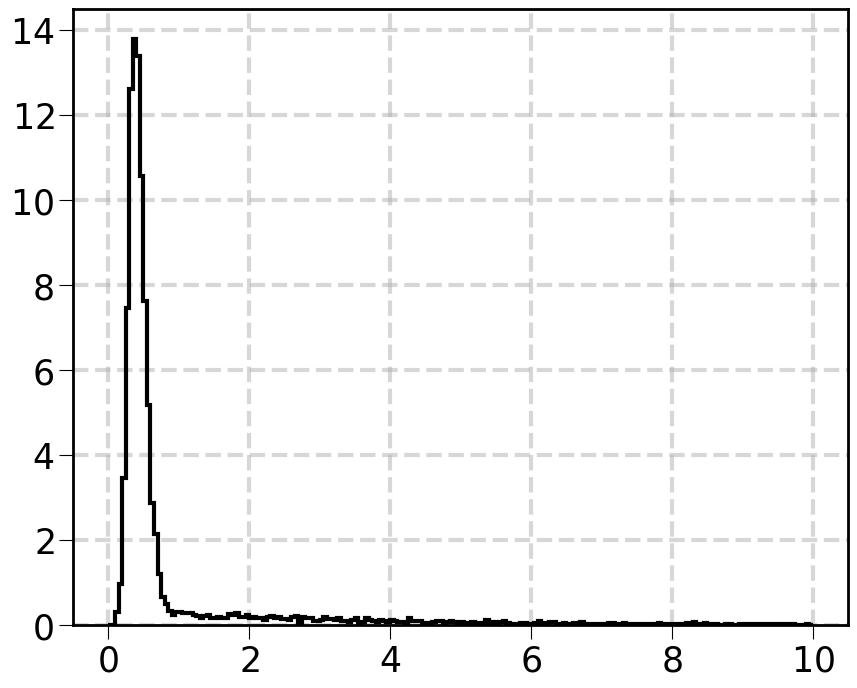

In [17]:
df = filter_df(data, gas="naturalXe", p=4.8)
bins = np.linspace(0, 10, 201)
normhist(df.dr, bins)
plt.grid()

In [34]:
bins_xe = np.linspace(0,  6, 401)
bins_ar = np.linspace(0, 20, 401)

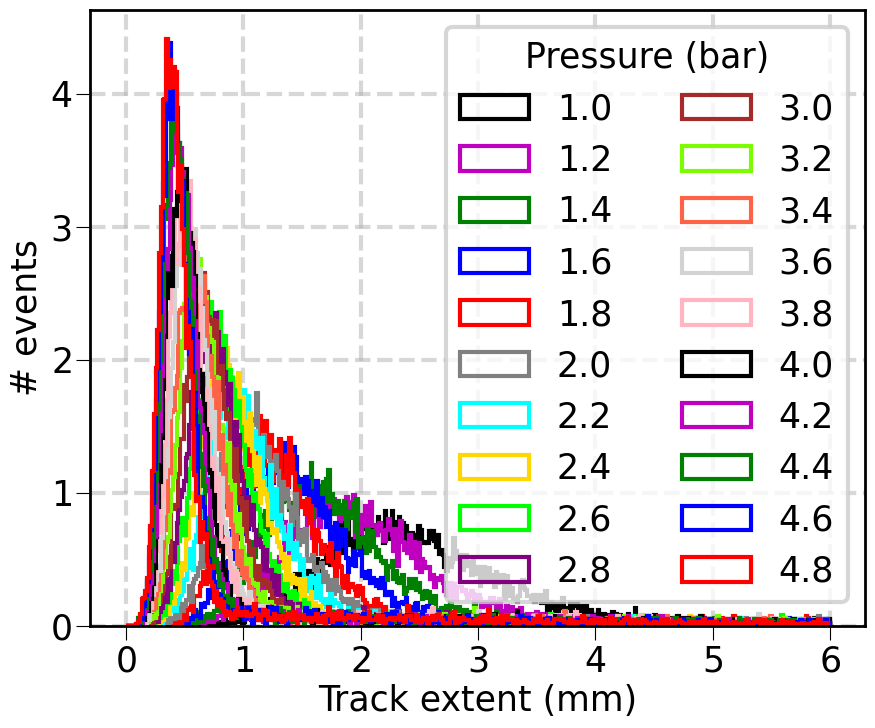

In [35]:
df   = filter_df(data, gas="naturalXe")
for p, df in df.groupby("p"):
    normhist(df.dr, bins_xe, label=str(p))
    
plt.xlabel("Track extent (mm)")
plt.ylabel("# events")
plt.legend(title="Pressure (bar)", ncol=2)
plt.grid()

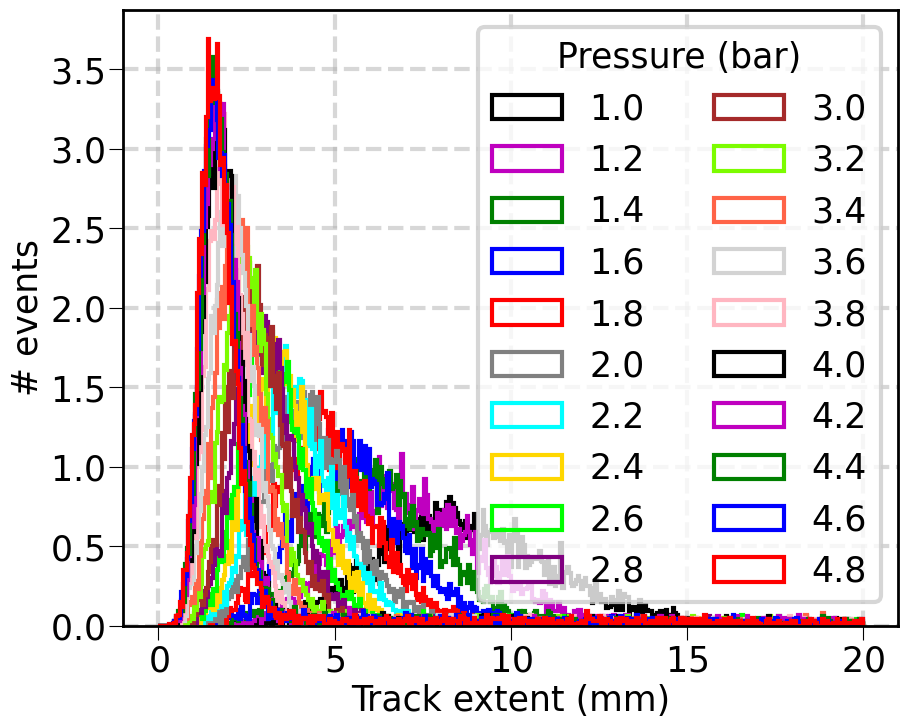

In [36]:
df   = filter_df(data, gas="GAr")
for p, df in df.groupby("p"):
    normhist(df.dr, bins_ar, label=str(p))
    
plt.xlabel("Track extent (mm)")
plt.ylabel("# events")
plt.legend(title="Pressure (bar)", ncol=2)
plt.grid()

In [38]:
def measure_peak(df, bins):
    y = np.histogram(df.dr, bins)[0]
    i = np.argwhere(y > y.max()/2).flatten()
    p = bins[i].mean() + np.diff(bins)[0]/2
    w = bins[i[-1] + 1] - bins[i[0]]
    return pd.DataFrame(dict(mu=p, fwhm=w), index=[0])

In [43]:
df_xe = filter_df(data, gas="naturalXe").groupby("p").apply(measure_peak, bins_xe).reset_index(level=1, drop=True).reset_index()
df_ar = filter_df(data, gas="GAr"      ).groupby("p").apply(measure_peak, bins_ar).reset_index(level=1, drop=True).reset_index()

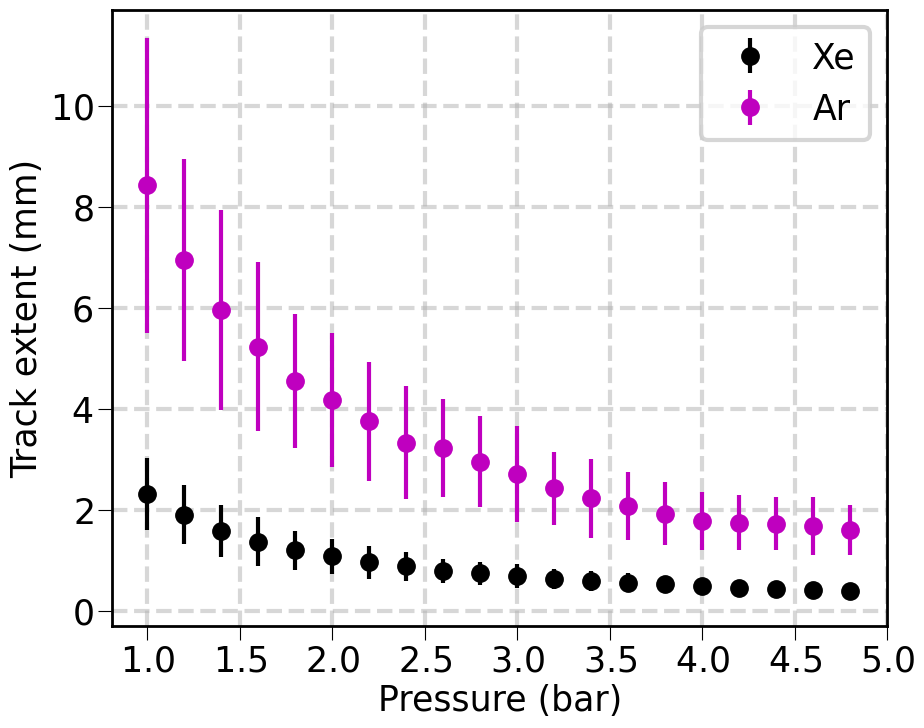

In [52]:

df = df_xe
plt.errorbar(df.p, df.mu, df.fwhm/2, fmt=".", label="Xe")
df = df_ar
plt.errorbar(df.p, df.mu, df.fwhm/2, fmt=".", label="Ar")

plt.xticks(np.arange(1, 5.1, 0.5))
#plt.xlim(None, 5)
plt.xlabel("Pressure (bar)")
plt.ylabel("Track extent (mm)")
plt.legend()
plt.grid()